# 08: EconML Causal ML Estimators

The goal is to use causal ML estimators directly and compare them with the manual AIPW workflow.

Earlier notebooks implemented IPW, AIPW, heterogeneous effects, policy simulation, sensitivity checks, and stronger ML nuisance models. This notebook adds two estimators from EconML:

- `DRLearner`: a doubly robust meta-learner for treatment effects.
- `CausalForestDML`: a causal forest estimator for heterogeneous treatment effects.

The purpose is to compare estimates, inspect CATE patterns, and decide whether the causal story is stable under standard causal-ML tools. The purpose is to compare estimates, inspect CATE patterns, and decide whether the causal story is stable under standard causal-ML tools.

<!-- dataset-experiment-context -->
## Dataset and Design Context

This project uses the Microsoft News Dataset (MIND) impression logs. The working table is an impression-item panel: each row is one news item displayed inside a user impression slate.

The data come from a real observational ranking log. Top-3 exposure was created by a production ranker, so assignment must be treated as confounded. The treatment is top-3 exposure, the outcome is click-through, and the main causal risk is that the production ranker likely used relevance, freshness, and intent signals that remain only partly observed in the public data.

The project should therefore be read as an offline causal measurement and experiment-prioritization workflow. Naive rank-position click differences are descriptive. Adjusted estimates, overlap checks, heterogeneous effects, and policy simulations are used to decide what would be credible enough to test online.

**Role of this notebook.** This notebook uses EconML estimators to compare causal-ML estimates, heterogeneous effects, feature importance, and targeting implications with the hand-built workflow.

<!-- mathematical-setup -->

## Mathematical Setup

Causal machine learning focuses on conditional effects across covariate profiles. The estimand is

$$
\tau(x)=\mathbb{E}\left[Y_i(1)-Y_i(0)\mid X_i=x\right].
$$

Orthogonal learners estimate treatment effects after removing predictable outcome and treatment variation. A residualized moment has the form

$$
Y_i-\widehat m(X_i) \approx \tau(X_i)\{T_i-\widehat e(X_i)\}+\varepsilon_i,
$$

where \(\widehat m(X_i)\) predicts the outcome and \(\widehat e(X_i)\) predicts treatment. Causal forests then search for splits that reveal stable treatment-effect heterogeneity.


## Why Add EconML?

Manual AIPW is valuable because it shows the mechanics. EconML adds mature implementations of causal ML estimators that are commonly used in applied treatment-effect work.

This notebook answers three questions:

1. Does `DRLearner` produce an ATE directionally similar to manual AIPW?
2. Does `CausalForestDML` produce an ATE directionally similar to manual AIPW?
3. What does the estimated CATE distribution suggest about where top-3 placement matters most?

A reviewer should see this as an extension of the earlier causal workflow that still depends on careful diagnostics.

#### Setup

This cell imports standard data-science libraries, LightGBM nuisance models, preprocessing tools, and the EconML estimators. We also suppress a specific sklearn/LightGBM feature-name warning that appears after preprocessing converts dataframes into encoded matrices.

In [1]:
from pathlib import Path
import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np

# Compatibility for older SHAP versions imported by EconML with NumPy 2.x.
if not hasattr(np, "bool8"):
    np.bool8 = np.bool_
if not hasattr(np, "obj2sctype"):
    def _obj2sctype(obj):
        try:
            return np.dtype(obj).type
        except TypeError:
            if isinstance(obj, type) and issubclass(obj, np.generic):
                return obj
            return np.asarray(obj).dtype.type

    np.obj2sctype = _obj2sctype

import pandas as pd
import seaborn as sns
from econml.dml import CausalForestDML
from econml.dr import DRLearner
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names.*",
    category=UserWarning,
)


IPython could not be loaded!


This cell prepares the notebook environment for advanced causal ML estimators and CATE analysis. There is no substantive model result yet; the important outcome is that the imports and display settings are ready so the next cells can focus on the data and causal question.


#### Load The Processed MIND Table

This cell loads the same processed MIND-small sample used in previous notebooks. Each row represents one displayed news item inside an impression. The treatment is whether that item was shown in the top 3, and the outcome is whether it was clicked.

In [2]:
DATA_RELATIVE_PATH = Path("data/processed/mind_small_impressions_train_sample.parquet")
PROJECT_ROOT = next(
    path
    for path in [Path.cwd(), *Path.cwd().parents]
    if (path / DATA_RELATIVE_PATH).exists()
)

DATA_PATH = PROJECT_ROOT / DATA_RELATIVE_PATH
df = pd.read_parquet(DATA_PATH)

df.shape


The loaded table preview and shape confirm that the notebook is using the expected processed dataset. This check anchors the rest of the analysis, because all treatment, outcome, and covariate definitions depend on these columns being present and correctly typed.


## Causal Setup

We keep the same treatment and outcome used throughout the project:

- **Treatment** `T`: `is_top_3 = 1`, meaning the item appeared in rank positions 1, 2, or 3.
- **Control**: `is_top_3 = 0`, meaning the item appeared below rank 3.
- **Outcome** `Y`: `clicked`, whether the user clicked the displayed item.
- **Covariates** `X`: user-history, item, category, time, and exposure features.

The estimand is still the average treatment effect:

`E[Y(1) - Y(0)]`

EconML also gives us individual treatment-effect estimates, usually called CATE estimates.

#### Create A Fixed Modeling Sample

This cell creates a fixed random sample for EconML modeling. Causal forests and DR learners are more expensive than the earlier descriptive analysis, so a moderate sample keeps the notebook interactive. The same sample is used for manual AIPW, DRLearner, and CausalForestDML so their estimates are comparable.

In [3]:
MODEL_SAMPLE_SIZE = 20_000
RANDOM_STATE = 42

model_df = (
    df.sample(n=min(len(df), MODEL_SAMPLE_SIZE), random_state=RANDOM_STATE)
    .reset_index(drop=True)
    .copy()
)

model_df["treatment"] = model_df["is_top_3"].astype(int)
model_df["outcome"] = model_df["clicked"].astype(float)
model_df["log_item_exposures"] = np.log1p(model_df["item_exposures"])
model_df["treatment_label"] = np.where(model_df["treatment"] == 1, "top_3", "rank_4_plus")

pd.Series(
    {
        "rows": len(model_df),
        "treatment_rate_top_3": model_df["treatment"].mean(),
        "click_rate": model_df["outcome"].mean(),
        "unique_users": model_df["user_id"].nunique(),
        "unique_items": model_df["news_id"].nunique(),
    }
)


rows                   20000.0000
treatment_rate_top_3       0.0811
click_rate                 0.0399
unique_users            8516.0000
unique_items            3352.0000
dtype: float64

This cell defines the working analysis sample and standardizes treatment/outcome columns. Fixing this sample early keeps later model comparisons fair because each estimator works on the same rows and target definition.


### Feature Matrix

EconML estimators expect numeric matrices. We therefore preprocess numeric and categorical features into one matrix. Numeric features are imputed and standardized. Categorical features are imputed and one-hot encoded with rare-level grouping.

We avoid `item_clicks` and `item_ctr` as model inputs because those columns are computed from click outcomes in this sample.

#### Define Features For Treatment-Effect Modeling

This cell defines the same covariates used in earlier notebooks: user-history size, slate size, title/abstract length, time context, item exposure, and content category metadata. These features are used as both confounders and effect modifiers in the EconML estimators.

In [4]:
numeric_features = [
    "history_len",
    "candidate_set_size",
    "title_length",
    "abstract_length",
    "hour",
    "day_of_week",
    "log_item_exposures",
]
categorical_features = ["category", "subcategory"]
feature_cols = numeric_features + categorical_features

Y = model_df["outcome"].to_numpy()
T = model_df["treatment"].to_numpy()

feature_cols


['history_len',
 'candidate_set_size',
 'title_length',
 'abstract_length',
 'hour',
 'day_of_week',
 'log_item_exposures',
 'category',
 'subcategory']

The feature lists define what information is allowed into the adjustment models. These are pre-treatment or contextual variables intended to reduce confounding without using the outcome itself as an input.


#### Build The Encoded Feature Matrix

This cell fits the preprocessing pipeline and creates `X_matrix`, the numeric feature matrix used by manual AIPW, DRLearner, and CausalForestDML. The one-hot encoder groups infrequent categories so the matrix stays reasonably compact.

In [5]:
# Build the encoded feature matrix.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="infrequent_if_exist",
                            min_frequency=100,
                            sparse_output=False,
                        ),
                    ),
                ]
            ),
            categorical_features,
        ),
    ],
    sparse_threshold=0,
)

X_matrix = preprocessor.fit_transform(model_df[feature_cols])
feature_names = preprocessor.get_feature_names_out()

pd.Series(
    {
        "rows": X_matrix.shape[0],
        "encoded_features": X_matrix.shape[1],
        "treatment_rate": T.mean(),
        "outcome_rate": Y.mean(),
    }
)


rows               20000.0000
encoded_features      73.0000
treatment_rate         0.0811
outcome_rate           0.0399
dtype: float64

The encoded feature matrix converts mixed numeric and categorical covariates into a model-ready design matrix. This is the handoff from tabular feature engineering to causal ML estimators that expect numeric arrays.


### Manual AIPW Benchmark

Before using EconML, we compute a manual cross-fitted AIPW estimate on the same sample and feature matrix. This gives a familiar benchmark from earlier notebooks.

The manual estimator uses LightGBM for the propensity and outcome nuisance models.

#### Define A Manual Cross-Fitted AIPW Helper

This cell defines the benchmark estimator. It cross-fits a propensity model and an outcome model, predicts counterfactual click probabilities, computes one AIPW score per row, and returns an ATE summary. This is the same basic logic as notebook 3, adapted to the encoded feature matrix.

In [6]:
# Define a manual cross-fitted AIPW helper.
def make_lgbm_classifier(n_estimators=100):
    """
    Create a LightGBM classifier for treatment or click modeling.
    
    Idea
    ----
    The classifier is used as a flexible nuisance model where nonlinear covariate relationships may matter for propensity or binary outcome prediction.
    
    Parameters
    ----------
    n_estimators : object
        Project-specific input named `n_estimators` used by this helper.
    
    Returns
    -------
    lightgbm.LGBMClassifier
        Configured LightGBM classifier with project-level defaults.
    """
    return lgb.LGBMClassifier(
        objective="binary",
        n_estimators=n_estimators,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=100,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )


def make_lgbm_regressor(n_estimators=100):
    """
    Create a LightGBM regressor for continuous or pseudo-outcome modeling.
    
    Idea
    ----
    The regressor is used for flexible outcome, CATE, or g-computation components where nonlinear prediction improves adjustment.
    
    Parameters
    ----------
    n_estimators : object
        Project-specific input named `n_estimators` used by this helper.
    
    Returns
    -------
    lightgbm.LGBMRegressor
        Configured LightGBM regressor with project-level defaults.
    """
    return lgb.LGBMRegressor(
        objective="regression",
        n_estimators=n_estimators,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=100,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )


def manual_cross_fitted_aipw(X, T, Y, n_folds=2, eps=0.01):
    """
    Compute a manual cross-fitted AIPW estimate for comparison with EconML.
    
    Idea
    ----
    This benchmark keeps the nuisance-model logic visible before comparing against library estimators for heterogeneous treatment effects.
    
    Parameters
    ----------
    X : object
        Feature matrix.
    T : object
        Treatment vector.
    Y : object
        Outcome vector.
    n_folds : object
        Number of cross-fitting folds.
    eps : object
        Small positive value used to avoid division by zero.
    
    Returns
    -------
    dict
        Manual AIPW estimate and out-of-fold nuisance predictions.
    """
    e_hat = np.zeros(len(Y))
    mu1_hat = np.zeros(len(Y))
    mu0_hat = np.zeros(len(Y))
    propensity_metrics = []
    outcome_metrics = []

    splitter = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    for fold, (train_idx, valid_idx) in enumerate(splitter.split(X, T), start=1):
        X_train, X_valid = X[train_idx], X[valid_idx]
        T_train, T_valid = T[train_idx], T[valid_idx]
        Y_train, Y_valid = Y[train_idx], Y[valid_idx]

        propensity_model = make_lgbm_classifier()
        propensity_model.fit(X_train, T_train)
        e_valid = propensity_model.predict_proba(X_valid)[:, 1]
        e_hat[valid_idx] = e_valid

        outcome_model = make_lgbm_regressor()
        outcome_model.fit(np.column_stack([T_train, X_train]), Y_train)
        y_valid_hat = outcome_model.predict(np.column_stack([T_valid, X_valid]))

        mu1_hat[valid_idx] = outcome_model.predict(np.column_stack([np.ones(len(X_valid)), X_valid]))
        mu0_hat[valid_idx] = outcome_model.predict(np.column_stack([np.zeros(len(X_valid)), X_valid]))

        propensity_metrics.append(
            {
                "fold": fold,
                "roc_auc": roc_auc_score(T_valid, e_valid),
                "average_precision": average_precision_score(T_valid, e_valid),
                "brier_score": brier_score_loss(T_valid, e_valid),
            }
        )
        outcome_metrics.append(
            {
                "fold": fold,
                "roc_auc": roc_auc_score(Y_valid, y_valid_hat),
                "average_precision": average_precision_score(Y_valid, y_valid_hat),
                "brier_score": brier_score_loss(Y_valid, np.clip(y_valid_hat, 0, 1)),
            }
        )

    e = np.clip(e_hat, eps, 1 - eps)
    aipw_scores = (mu1_hat - mu0_hat) + T * (Y - mu1_hat) / e - (1 - T) * (Y - mu0_hat) / (1 - e)
    ate = aipw_scores.mean()
    se = aipw_scores.std(ddof=1) / np.sqrt(len(aipw_scores))

    summary = {
        "estimator": "manual_aipw_lgbm",
        "ate": ate,
        "standard_error": se,
        "ci_95_lower": ate - 1.96 * se,
        "ci_95_upper": ate + 1.96 * se,
        "cate_mean": np.nan,
        "cate_std": np.nan,
    }

    scored = pd.DataFrame(
        {
            "e_hat": e_hat,
            "mu1_hat": mu1_hat,
            "mu0_hat": mu0_hat,
            "aipw_score": aipw_scores,
        }
    )
    return scored, summary, pd.DataFrame(propensity_metrics), pd.DataFrame(outcome_metrics)


Cross-fitting creates out-of-sample nuisance predictions for treatment and outcome models. This reduces overfitting bias and makes the later doubly robust scores more credible. The practical implication is that poor overlap or extreme propensity scores would make the adjusted estimate depend on a narrow slice of comparable observations.


#### Run The Manual AIPW Benchmark

This cell runs the manual benchmark on the same sample that EconML will use. The output gives the AIPW ATE and an influence-function-style confidence interval based on the per-row AIPW scores.

In [7]:
manual_scored, manual_summary, manual_propensity_metrics, manual_outcome_metrics = manual_cross_fitted_aipw(
    X_matrix,
    T,
    Y,
    n_folds=2,
    eps=0.01,
)

pd.DataFrame([manual_summary])


,estimator,ate,standard_error,ci_95_lower,ci_95_upper,cate_mean,cate_std
0,manual_aipw_lgbm,-0.0070,0.0070,-0.0207,0.0068,NaN,NaN


The manual AIPW result anchors the advanced causal-ML notebook to the earlier project workflow. It gives a familiar benchmark before introducing EconML estimators. The practical implication is that poor overlap or extreme propensity scores would make the adjusted estimate depend on a narrow slice of comparable observations.


### EconML DRLearner

`DRLearner` is a doubly robust meta-learner. It uses nuisance models for treatment assignment and outcome prediction, then learns a final treatment-effect model.

Here we use LightGBM for the nuisance models and another LightGBM regressor as the final CATE model.

#### Fit DRLearner

This cell fits EconML's `DRLearner`. The model estimates a CATE for each row. The average of those CATE estimates gives a DRLearner ATE estimate that we can compare against manual AIPW.

In [8]:
dr_learner = DRLearner(
    model_propensity=make_lgbm_classifier(),
    model_regression=make_lgbm_regressor(),
    model_final=make_lgbm_regressor(),
    min_propensity=0.01,
    cv=2,
    random_state=RANDOM_STATE,
)

dr_learner.fit(Y, T, X=X_matrix)
drlearner_effect = dr_learner.effect(X_matrix)

drlearner_summary = {
    "estimator": "econml_drlearner_lgbm",
    "ate": drlearner_effect.mean(),
    "standard_error": np.nan,
    "ci_95_lower": np.nan,
    "ci_95_upper": np.nan,
    "cate_mean": drlearner_effect.mean(),
    "cate_std": drlearner_effect.std(ddof=1),
}

pd.DataFrame([drlearner_summary])


,estimator,ate,standard_error,ci_95_lower,ci_95_upper,cate_mean,cate_std
0,econml_drlearner_lgbm,-0.0064,NaN,NaN,NaN,-0.0064,0.1098


DRLearner estimates heterogeneous treatment effects by combining outcome modeling with residual correction. This is useful for checking whether advanced causal ML agrees with the manual doubly robust workflow.


### EconML CausalForestDML

`CausalForestDML` estimates heterogeneous treatment effects using an orthogonalized causal forest. It is especially useful for CATE analysis because it estimates both the average top-3 effect and how that effect varies across rows.

We use LightGBM nuisance models for outcome and treatment, then let the causal forest model treatment-effect heterogeneity.

#### Fit CausalForestDML

This cell fits the causal forest. `discrete_treatment=True` tells EconML that top-3 exposure is binary. The forest returns both an ATE estimate and per-row CATE estimates. The ATE interval comes from the forest's inference machinery.

In [9]:
# Fit CausalForestDML.
causal_forest = CausalForestDML(
    model_y=make_lgbm_regressor(),
    model_t=make_lgbm_classifier(),
    discrete_treatment=True,
    cv=2,
    n_estimators=160,
    min_samples_leaf=100,
    max_depth=12,
    max_samples=0.45,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    inference=True,
)

causal_forest.fit(Y, T, X=X_matrix)
cf_effect = causal_forest.effect(X_matrix)
cf_ate = causal_forest.ate(X=X_matrix)
cf_ci_lower, cf_ci_upper = causal_forest.ate_interval(X=X_matrix)

causalforest_summary = {
    "estimator": "econml_causal_forest_dml",
    "ate": cf_ate,
    "standard_error": np.nan,
    "ci_95_lower": cf_ci_lower,
    "ci_95_upper": cf_ci_upper,
    "cate_mean": cf_effect.mean(),
    "cate_std": cf_effect.std(ddof=1),
}

pd.DataFrame([causalforest_summary])


,estimator,ate,standard_error,ci_95_lower,ci_95_upper,cate_mean,cate_std
0,econml_causal_forest_dml,-0.0075,NaN,-0.0405,0.0255,-0.0075,0.0099


CausalForestDML provides a flexible forest-based view of treatment-effect heterogeneity. Its estimates are most useful when compared against the manual AIPW and DRLearner benchmarks. The teaching point is that weighting can reduce bias while also reducing usable information, so stability matters as much as the point estimate.


### ATE Comparison

Now we compare the three estimates:

- Manual cross-fitted AIPW with LightGBM nuisance models.
- EconML `DRLearner` with LightGBM nuisance and final models.
- EconML `CausalForestDML` with LightGBM nuisance models.

Agreement in sign and approximate magnitude is more important than exact equality because the estimators use different final effect models.

#### Build The ATE Comparison Table

This cell combines the manual and EconML summaries. The `ate` column is the estimated average effect of top-3 exposure on click probability. The CATE columns summarize the distribution of individual effect estimates when available.

In [10]:
ate_comparison = pd.DataFrame(
    [
        manual_summary,
        drlearner_summary,
        causalforest_summary,
    ]
)

ate_comparison


,estimator,ate,standard_error,ci_95_lower,ci_95_upper,cate_mean,cate_std
0,manual_aipw_lgbm,-0.0070,0.0070,-0.0207,0.0068,NaN,NaN
1,econml_drlearner_lgbm,-0.0064,NaN,NaN,NaN,-0.0064,0.1098
2,econml_causal_forest_dml,-0.0075,NaN,-0.0405,0.0255,-0.0075,0.0099


The comparison table places naive, adjusted, and model-based estimates side by side. Agreement increases confidence, while large differences reveal how much adjustment changes the raw ranking-position story.


#### Plot ATE Estimates

This cell visualizes the ATE estimates. The causal forest includes an interval from EconML. The manual AIPW estimate includes the influence-function-style interval. DRLearner is shown as a point estimate because this configuration lacks a simple built-in interval.

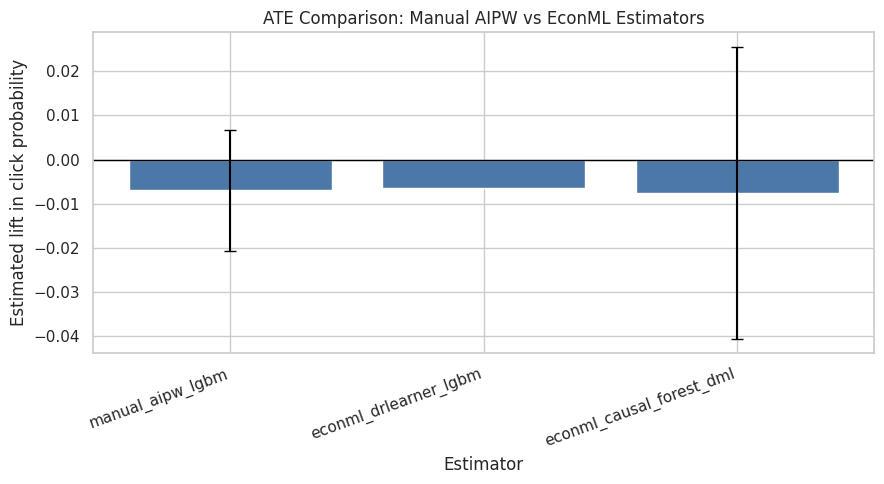

In [11]:
plot_df = ate_comparison.copy()
plot_df["lower_error"] = plot_df["ate"] - plot_df["ci_95_lower"]
plot_df["upper_error"] = plot_df["ci_95_upper"] - plot_df["ate"]

plt.figure(figsize=(9, 5))
plt.bar(plot_df["estimator"], plot_df["ate"], color="#4C78A8")
for i, row in plot_df.dropna(subset=["ci_95_lower", "ci_95_upper"]).iterrows():
    plt.errorbar(
        x=i,
        y=row["ate"],
        yerr=[[row["lower_error"]], [row["upper_error"]]],
        color="black",
        capsize=4,
        fmt="none",
    )
plt.axhline(0, color="black", linewidth=1)
plt.title("ATE Comparison: Manual AIPW vs EconML Estimators")
plt.ylabel("Estimated lift in click probability")
plt.xlabel("Estimator")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()


The estimate plot makes the difference between estimators easy to compare. It helps communicate whether the causal adjustment materially changes the naive lift estimate. The comparison should be read together with overlap and nuisance-model diagnostics because causal forests can reveal heterogeneity only within the part of the feature space supported by the observed ranking logs.


### CATE Distributions

CATE estimates describe treatment-effect heterogeneity. The question shifts from average top-3 exposure effects to row-level variation in the estimated effect.

These CATE estimates should be interpreted cautiously. They are model-based estimates from observational data. Individual counterfactual effects remain unobserved.

#### Plot DRLearner And Causal Forest CATE Distributions

This cell plots the distribution of row-level CATE estimates from DRLearner and CausalForestDML. A wide distribution suggests heterogeneity. Differences between estimators indicate model dependence.

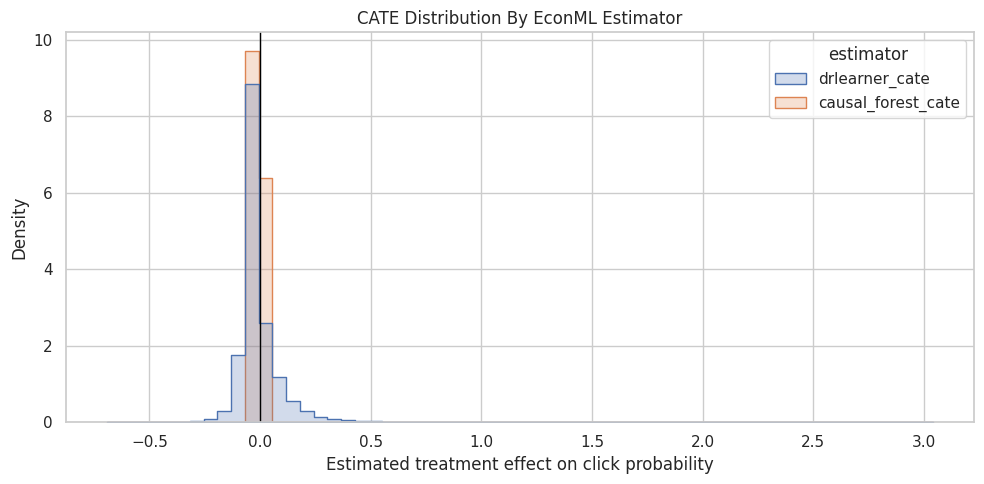

In [12]:
cate_df = pd.DataFrame(
    {
        "drlearner_cate": drlearner_effect,
        "causal_forest_cate": cf_effect,
    }
)
cate_long = cate_df.melt(var_name="estimator", value_name="cate")

plt.figure(figsize=(10, 5))
sns.histplot(data=cate_long, x="cate", hue="estimator", bins=60, element="step", stat="density", common_norm=False)
plt.axvline(0, color="black", linewidth=1)
plt.title("CATE Distribution By EconML Estimator")
plt.xlabel("Estimated treatment effect on click probability")
plt.ylabel("Density")
plt.tight_layout()


The CATE output describes how estimated treatment effects vary across rows or segments. This is the advanced causal-ML version of heterogeneity analysis and helps identify where ranking exposure may be most valuable.


#### Summarize CATE Distributions

This cell reports percentiles for the CATE estimates. The percentiles make it easier to see whether estimated effects are mostly positive, mostly negative, or mixed across rows.

In [13]:
cate_long.groupby("estimator")["cate"].describe(percentiles=[0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99])


,count,mean,std,min,1%,5%,10%,50%,90%,95%,99%,max
estimator,,,,,,,,,,,,
causal_forest_cate,20000.0000,-0.0075,0.0099,-0.0425,-0.0269,-0.0212,-0.0186,-0.0087,0.0050,0.0106,0.0220,0.0479
drlearner_cate,20000.0000,-0.0064,0.1098,-0.6900,-0.1835,-0.1052,-0.0788,-0.0305,0.0955,0.1674,0.3883,3.0393


The CATE output describes how estimated treatment effects vary across rows or segments. This is the advanced causal-ML version of heterogeneity analysis and helps identify where ranking exposure may be most valuable.


### Segment-Level CATE Summaries

Segment summaries translate row-level CATE estimates into product language. We look at broad category, user-history depth, candidate-set size, item exposure, and time of day.

It summarizes model-estimated heterogeneity within the existing identification strategy. It is a way to summarize model-estimated heterogeneity.

#### Create Segment Columns And Attach CATE Estimates

This cell adds the EconML CATE estimates back to the modeling dataframe and creates bucketed segment columns. These segments match the product-relevant views used in earlier notebooks.

In [14]:
model_df["drlearner_cate"] = drlearner_effect
model_df["causal_forest_cate"] = cf_effect

model_df["history_bucket"] = pd.cut(
    model_df["history_len"],
    bins=[-1, 0, 10, 30, 100, np.inf],
    labels=["0", "1-10", "11-30", "31-100", "101+"],
)
model_df["candidate_set_bucket"] = pd.cut(
    model_df["candidate_set_size"],
    bins=[0, 10, 25, 50, 100, np.inf],
    labels=["1-10", "11-25", "26-50", "51-100", "101+"],
    include_lowest=True,
)
model_df["item_exposure_quartile"] = pd.qcut(
    model_df["item_exposures"].rank(method="first"),
    q=4,
    labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"],
)
model_df["time_of_day"] = pd.cut(
    model_df["hour"],
    bins=[-1, 5, 11, 16, 20, 23],
    labels=["overnight", "morning", "afternoon", "evening", "late_evening"],
)

model_df[["drlearner_cate", "causal_forest_cate", "history_bucket", "item_exposure_quartile"]].head()


,drlearner_cate,causal_forest_cate,history_bucket,item_exposure_quartile
0,0.1008,-0.0090,31-100,Q2
1,-0.2050,0.0046,31-100,Q2
2,-0.1798,0.0019,31-100,Q2
3,-0.0287,-0.0094,31-100,Q3
4,-0.0613,0.0105,31-100,Q2


The segment columns translate raw covariates into product-readable groups. This prepares the analysis for heterogeneity and policy simulation, where segment-level effects are easier to act on than row-level scores.


#### Define A Segment CATE Summary Helper

This cell defines a helper that averages CATE estimates within each segment and computes a simple standard error. The standard error reflects variation in estimated CATE values inside the segment. Full causal-estimator uncertainty would require a heavier bootstrap.

In [15]:
# Define a segment CATE summary helper.
def summarize_cate_by_segment(data, segment_col, cate_col, min_rows=500):
    """
    Summarize CATE estimates by observed segment.
    
    Idea
    ----
    The helper aggregates individual treatment-effect predictions so heterogeneous ranking effects can be discussed in product-relevant groups.
    
    Parameters
    ----------
    data : object
        Input analysis table for the current project step.
    segment_col : object
        Column defining the segment to summarize.
    cate_col : object
        Project-specific input named `cate_col` used by this helper.
    min_rows : object
        Minimum rows required to keep a segment.
    
    Returns
    -------
    pandas.DataFrame
        Segment-level CATE summary with counts and average effects.
    """
    rows = []
    for segment, group in data.groupby(segment_col, observed=True, dropna=False):
        if len(group) < min_rows:
            continue
        values = group[cate_col].to_numpy()
        mean = values.mean()
        se = values.std(ddof=1) / np.sqrt(len(values))
        rows.append(
            {
                "segment_col": segment_col,
                "segment": str(segment),
                "cate_estimator": cate_col,
                "rows": len(group),
                "mean_cate": mean,
                "standard_error": se,
                "ci_95_lower": mean - 1.96 * se,
                "ci_95_upper": mean + 1.96 * se,
            }
        )
    return pd.DataFrame(rows).sort_values("mean_cate", ascending=False).reset_index(drop=True)


segment_columns = ["category", "history_bucket", "candidate_set_bucket", "item_exposure_quartile", "time_of_day"]


The CATE output describes how estimated treatment effects vary across rows or segments. This is the advanced causal-ML version of heterogeneity analysis and helps identify where ranking exposure may be most valuable.


#### Build Segment-Level CATE Tables

This cell computes segment-level CATE summaries for both DRLearner and CausalForestDML. It then combines them into one table so we can compare model-estimated heterogeneity across product segments.

In [16]:
segment_tables = []
for segment_col in segment_columns:
    for cate_col in ["drlearner_cate", "causal_forest_cate"]:
        segment_tables.append(summarize_cate_by_segment(model_df, segment_col, cate_col, min_rows=500))

all_segment_cate = pd.concat(segment_tables, ignore_index=True)
all_segment_cate.sort_values("mean_cate", ascending=False).head(20)


,segment_col,segment,cate_estimator,rows,mean_cate,standard_error,ci_95_lower,ci_95_upper
48,time_of_day,overnight,drlearner_cate,2822,0.0354,0.0036,0.0283,0.0424
30,candidate_set_bucket,1-10,drlearner_cate,795,0.0261,0.0051,0.0162,0.0360
0,category,travel,drlearner_cate,1061,0.0251,0.0031,0.0191,0.0312
22,history_bucket,101+,drlearner_cate,1432,0.0226,0.0051,0.0126,0.0327
1,category,autos,drlearner_cate,901,0.0087,0.0033,0.0022,0.0152
23,history_bucket,31-100,drlearner_cate,6247,0.0075,0.0017,0.0042,0.0107
2,category,sports,drlearner_cate,2004,0.0070,0.0026,0.0020,0.0120
3,category,news,drlearner_cate,5380,0.0055,0.0020,0.0015,0.0095
31,candidate_set_bucket,26-50,drlearner_cate,4678,0.0044,0.0017,0.0012,0.0077
53,time_of_day,overnight,causal_forest_cate,2822,0.0003,0.0002,-0.0002,0.0008


The CATE output describes how estimated treatment effects vary across rows or segments. This is the advanced causal-ML version of heterogeneity analysis and helps identify where ranking exposure may be most valuable.


#### Plot Category-Level CATE Summaries

This cell plots average CATE by broad category for both EconML estimators. Category-level summaries are easy to communicate in a product review. They should be treated as model-estimated heterogeneity under the observational design.

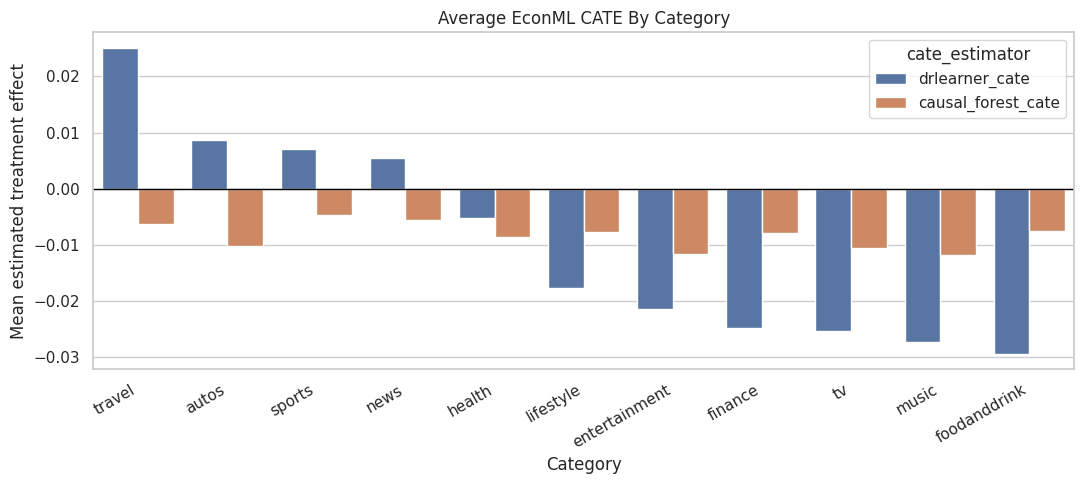

In [17]:
category_cate = all_segment_cate.query("segment_col == 'category'")

plt.figure(figsize=(11, 5))
sns.barplot(data=category_cate, x="segment", y="mean_cate", hue="cate_estimator")
plt.axhline(0, color="black", linewidth=1)
plt.title("Average EconML CATE By Category")
plt.xlabel("Category")
plt.ylabel("Mean estimated treatment effect")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()


The category plot highlights which content groups have the largest estimated ranking lift. This gives the project a more product-facing story than a single global average effect.


#### Plot Bucketed Segment CATE Summaries

This cell plots average CATE by user-history bucket, candidate-set-size bucket, item-exposure quartile, and time of day. These plots help identify product contexts where top-3 placement appears more or less valuable.

Text(0.5, 1.03, 'Average EconML CATE By Product Segment')

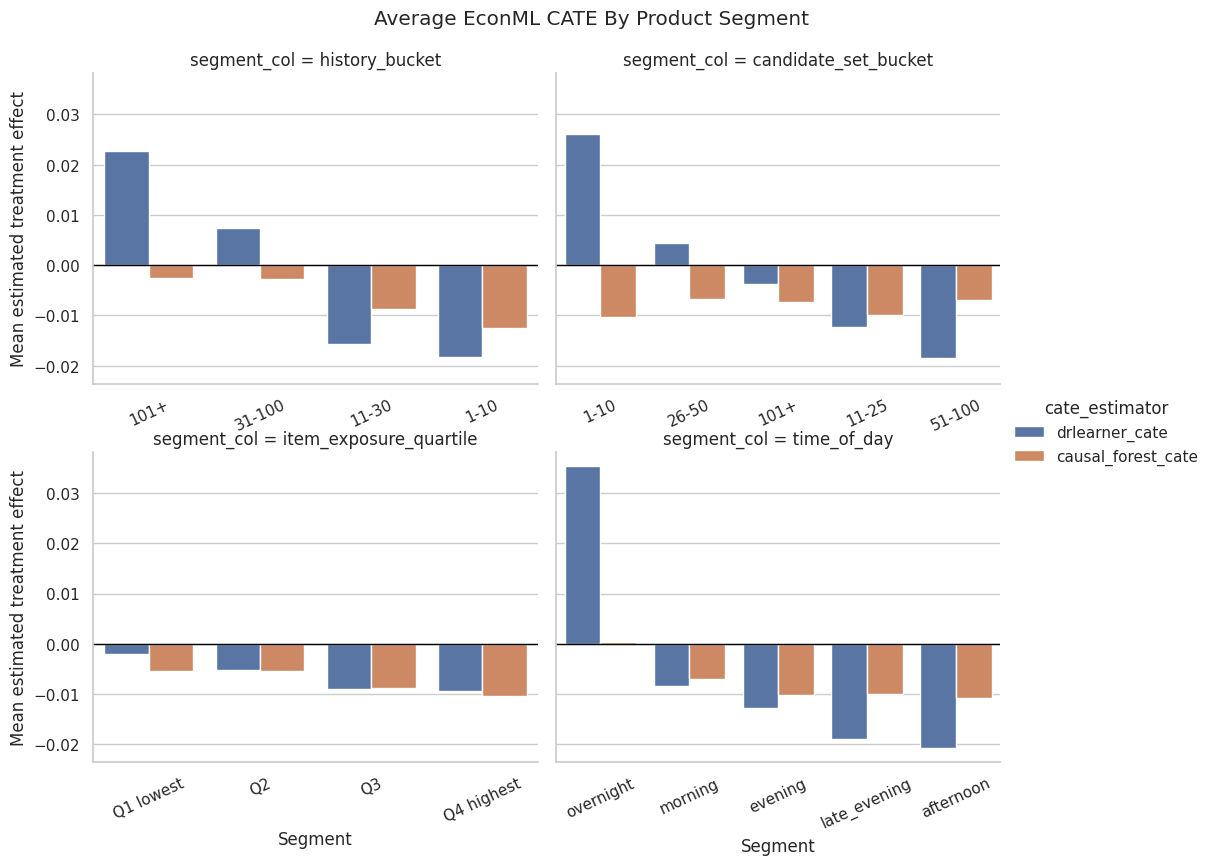

In [18]:
bucket_cate = all_segment_cate.query("segment_col != 'category'").copy()

g = sns.catplot(
    data=bucket_cate,
    x="segment",
    y="mean_cate",
    hue="cate_estimator",
    col="segment_col",
    kind="bar",
    col_wrap=2,
    sharex=False,
    sharey=True,
    height=4,
    aspect=1.3,
)
for ax in g.axes.flat:
    ax.axhline(0, color="black", linewidth=1)
    ax.tick_params(axis="x", rotation=25)
g.set_axis_labels("Segment", "Mean estimated treatment effect")
g.fig.suptitle("Average EconML CATE By Product Segment", y=1.03)


The CATE output describes how estimated treatment effects vary across rows or segments. This is the advanced causal-ML version of heterogeneity analysis and helps identify where ranking exposure may be most valuable.


### Causal Forest Feature Importance

Causal forest feature importance describes treatment-effect heterogeneity. A feature can be important here if it helps split the forest into groups with different estimated treatment effects.

This helps interpret the causal forest as a heterogeneity model.

#### Extract And Plot Causal Forest Feature Importance

This cell pairs `CausalForestDML.feature_importances_` with the encoded feature names. The plot shows which features the causal forest used most to model treatment-effect heterogeneity.

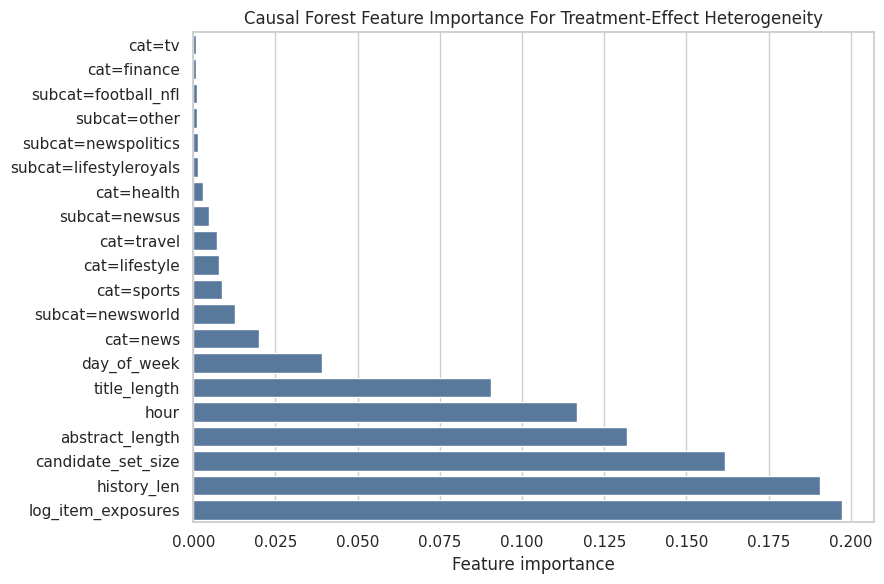

In [19]:
# Extract and plot causal forest feature importance.
def clean_feature_name(name):
    """
    Clean encoded feature names for display.
    
    Idea
    ----
    Model pipelines often prepend transformer names to one-hot encoded variables; this helper converts those names into readable labels for plots and tables.
    
    Parameters
    ----------
    name : object
        Artifact name or feature name to clean.
    
    Returns
    -------
    str
        Human-readable feature name.
    """
    return (
        name.replace("num__", "")
        .replace("cat__", "")
        .replace("category_", "cat=")
        .replace("subcategory_", "subcat=")
        .replace("infrequent_sklearn", "other")
    )


cf_importance = (
    pd.DataFrame(
        {
            "feature": feature_names,
            "importance": causal_forest.feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .head(20)
)
cf_importance["feature_clean"] = cf_importance["feature"].map(clean_feature_name)

plt.figure(figsize=(9, 6))
sns.barplot(data=cf_importance.sort_values("importance"), x="importance", y="feature_clean", color="#4C78A8")
plt.title("Causal Forest Feature Importance For Treatment-Effect Heterogeneity")
plt.xlabel("Feature importance")
plt.ylabel("")
plt.tight_layout()


CausalForestDML provides a flexible forest-based view of treatment-effect heterogeneity. Its estimates are most useful when compared against the manual AIPW and DRLearner benchmarks. This keeps the analysis auditable: a reader can trace the final claim back to the exact table, figure, or markdown artifact that produced it.


## Interpretation Checklist

Use this notebook to answer:

1. Is the manual AIPW ATE directionally consistent with EconML's `DRLearner`?
2. Is the manual AIPW ATE directionally consistent with `CausalForestDML`?
3. Do DRLearner and CausalForestDML imply similar CATE distributions?
4. Which product segments show higher or lower estimated CATE?
5. Which features appear important for causal-forest heterogeneity?

Taken together, these checks compare the hand-built AIPW workflow with standard causal-ML estimators. Agreement across manual AIPW, DRLearner, and CausalForestDML supports a more stable causal interpretation. Differences are evidence about estimator sensitivity or heterogeneity and should shape the uncertainty discussion.